In [ ]:
# %% Imports and config
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import torch
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy

from sklearn.metrics import mean_absolute_error, mean_squared_error


# --- CONFIG ---
BATCH_SIZE = 256
EPOCHS = 25
LEARNING_RATE = 1e-5
KFOLDS = 5
TEST_SPLIT = 0.2
SEED = 2222

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, csv_files, step=1, input_range=(-1, 1), target_range=(-1, 1), value_clip=1e5):
        self.data = []
        self.target = []

        print(f"📂 Processing {len(csv_files)} files")
        if not csv_files:
            raise ValueError("❌ No CSV files provided.")

        for file in csv_files:
            try:
                df = pd.read_csv(file)
                '''if df.shape[1] < 6:
                    print(f"⚠️ Skipping {file}: too few columns")
                    continue'''

                # Pretpostavka: kolone su [time, value, next_time, next_value]
                df = df.iloc[::step, :]
                df.columns = ['time', 'value', "top", "bot", 'time_step', "L_value", "next_value"]

                time = df['time'].values
                time_step = df['time_step'].values
                value = df['value'].values
                next_value = df['next_value'].values
                top = df['top'].values
                bot = df['bot'].values
                L_val = df['L_value'].values

                # Čišćenje
                valid_mask = (
                    np.isfinite(time) &
                    np.isfinite(time_step) &
                    np.isfinite(top) &
                    np.isfinite(bot) &
                    np.isfinite(value) &
                    np.isfinite(next_value) &
                    (np.abs(value) < value_clip) &
                    (np.abs(next_value) < value_clip) &
                    (np.abs(L_val) < value_clip)
                )



                if not np.any(valid_mask):
                    print(f"⚠️ Skipping {file}: no valid rows after filtering")
                    continue

                time       = time       [valid_mask]
                value      = value      [valid_mask]
                next_value = next_value [valid_mask]
                L_val      = L_val      [valid_mask]

                # Novi ulazni format: [time, next_time, value]
                inputs = np.stack([value, top, bot, time_step, L_val], axis=1)
                self.data.append(inputs)
                self.target.append(next_value)

            except Exception as e:
                print(f"❌ Failed to process {file}: {e}")
                continue

        # ✅ Finalna obrada
        self.data = np.concatenate(self.data, axis=0)
        self.target = np.concatenate(self.target, axis=0)

        # Normalizacija
        self.scaler_X = MinMaxScaler(feature_range=input_range)
        self.scaler_y = MinMaxScaler(feature_range=target_range)

        self.data = self.scaler_X.fit_transform(self.data)
        self.target = self.scaler_y.fit_transform(self.target.reshape(-1, 1)).flatten()

        print(f"✅ Loaded {len(self.data)} samples from {len(csv_files)} files.")
        print(f"📊 Input shape: {self.data.shape}, Target shape: {self.target.shape}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.float32),
            torch.tensor(self.target[idx], dtype=torch.float32)
        )

    def get_scalers(self):
        return self.scaler_X, self.scaler_y


In [66]:
class AdaptiveMixedActivation(nn.Module):
    def __init__(self, delta_init=0.0, epsilon_init=1.0):
        super().__init__()
        self.raw_delta = nn.Parameter(torch.tensor(float(delta_init)))
        self.raw_epsilon = nn.Parameter(torch.tensor(float(epsilon_init)))

    def forward(self, x):
        delta = self.raw_delta
        epsilon = self.raw_epsilon

        return (delta * torch.sin(epsilon * x))


In [ ]:
# === Custom Activation: Sine + Cosine Mixer ===
class SinCosActivation(nn.Module):
    def __init__(self, alpha=1.0, beta = 1.0, gamma = 1.0, delta = 1.0, epsilon = 0):
        super().__init__()
        self.alpha   = nn.Parameter(torch.tensor(alpha, dtype=torch.float32))
        self.beta    = nn.Parameter(torch.tensor(beta, dtype=torch.float32))
        self.gamma   = nn.Parameter(torch.tensor(gamma, dtype=torch.float32))
        self.delta   = nn.Parameter(torch.tensor(delta, dtype=torch.float32))
        self.epsilon = nn.Parameter(torch.tensor(epsilon, dtype=torch.float32))
    def forward(self, x):
        return ((self.delta * (torch.sin(self.alpha)) + (torch.cos(self.beta)) * self.gamma)  + self.epsilon)*x

# === Feedforward Network Using SinCos Activations ===
import torch.nn as nn

class FeedforwardNet(nn.Module):
    def __init__(self, input_size=5, hidden_layers=6, neurons_per_layer=256, output_size=1):
        super().__init__()

        layers = []
        prev_size = input_size

        for _ in range(hidden_layers):
            layers.append(nn.Linear(prev_size, neurons_per_layer))
            layers.append(SinCosActivation())  # Trenabilna aktivacija
            prev_size = neurons_per_layer

        layers.append(nn.Linear(prev_size, output_size))
        self.model = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)



In [68]:
# --- Nova Pick-One-Layer-Handles-Everything aktivacija ---
class AdaptiveMixedActivation(nn.Module):
    def __init__(self, delta_init=0.1, epsilon_init=0.1):
        super().__init__()
        self.raw_delta = nn.Parameter(torch.tensor(float(delta_init)))
        self.raw_epsilon = nn.Parameter(torch.tensor(float(epsilon_init)))

    def forward(self, x):
        delta = self.raw_delta
        epsilon = self.raw_epsilon

        return (delta * torch.sin(epsilon * x))


In [ ]:
def train_fold(model, train_loader, val_loader, device=device, lr=0.0001, weight_decay=1e-6, patience=4):
    criterion1 = nn.MSELoss() 
    criterion2 = nn.MultiLabelSoftMarginLoss()

    optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_model = None
    best_val_loss = float('inf')
    train_losses, val_losses = [], []
    epochs_without_improvement = 0

    # Log parametara aktivacione funkcije po epohi
    activation_logs = []
    triggered1 = False
    triggered2 = False
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        if epoch == 5 and not triggered:  
            lr = 1e-5
            optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
            
            print(f"Learning rate smanjen na {lr}")
            
        for i, (x, y) in enumerate(train_loader):
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            pred = model(x)
            y = y.view(-1, 1)

            mse          = criterion1(pred, y) # + criterion2(pred, y)
            peak_loss    = (pred.max() - y.max()).pow(2)
            trough_loss  = (pred.min() - y.min()).pow(2)
            loss         = mse + 0.8 * peak_loss + 0.8 * trough_loss

            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
            if loss.item() < 0.0005 and not triggered2 and triggered1:
                lr = 0.5e-7
                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr
                triggered2 = True
                print(f"🔻 Learning rate dodatno smanjen na {lr}")

            if train_loss < 0.005 and not triggered2:
                lr = 1e-7
                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr
                triggered2 = True  # Set the trigger so this block won't run again
                print(f"🔻 Learning rate smanjen na {lr}")

        avg_train = train_loss / len(train_loader)
        train_losses.append(avg_train)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                y = y.view(-1, 1)

                mse          = criterion1(pred, y) # + criterion2(pred, y)
                peak_loss    = (pred.max() - y.max()).pow(2)
                trough_loss  = (pred.min() - y.min()).pow(2)
                loss         = mse + 0.8 * peak_loss + 0.8 * trough_loss

                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)
        val_losses.append(avg_val)

        # === LOGOVANJE AKTIVACIONIH PARAMETARA ===
        epoch_params = []
        for module in model.modules():
            if isinstance(module, AdaptiveMixedActivation):
                epoch_params.append({
                    'alpha': module.raw_alpha.item(),
                    'beta': module.raw_beta.item(),
                    "gamma": module.raw_gamma.item()
                })
        activation_logs.append(epoch_params)

        print(f"Epoch {epoch+1}: Train {avg_train:.14f} | Val {avg_val:.14f}")
        for idx, p in enumerate(epoch_params):
            print(f"  ↪ Layer {idx+1} params: alpha={p['alpha']:.4f}, beta={p['beta']:.4f}, gamma={p['gamma']:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"⚠️ Early stopping at epoch {epoch+1} due to no improvement in validation loss.")
            break

    # Aktivacione parametre možeš vratiti zasebno ako želiš u analizi (ali ih ovde ne menjamo)
    return best_model, best_val_loss, train_losses, val_losses


In [70]:
def cross_validate(dataset, hidden_layers=6, neurons_per_layer=256, input_size = 5):
    indices = np.arange(len(dataset))
    np.random.shuffle(indices)
    test_size = int(TEST_SPLIT * len(indices))
    test_set = Subset(dataset, indices[:test_size])
    train_val_set = Subset(dataset, indices[test_size:])

    kfold = KFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    all_train, all_val = [], []
    best_model = None
    best_loss = float("inf")

    for fold, (train_idx, val_idx) in enumerate(kfold.split(range(len(train_val_set)))):
        print(f"\n--- Fold {fold+1} ---")
        train_subset = Subset(train_val_set, train_idx)
        val_subset = Subset(train_val_set, val_idx)

        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE)

        model = FeedforwardNet(
            input_size = input_size,
            hidden_layers = hidden_layers,
            neurons_per_layer = neurons_per_layer
        ).to(device)

        model_fold, val_loss, train_losses, val_losses = train_fold(model, train_loader, val_loader)

        all_train.append(train_losses)
        all_val.append(val_losses)

        if val_loss < best_loss:
            best_model = model_fold
            best_loss = val_loss

    return best_model, test_set, all_train, all_val, model


In [71]:
def plot_avg_loss_curves(train_losses, val_losses):
    max_len = max(len(t) for t in train_losses)

    def pad_with_nan(lst, target_len):
        return lst + [np.nan] * (target_len - len(lst))

    padded_train = np.array([pad_with_nan(t, max_len) for t in train_losses])
    padded_val = np.array([pad_with_nan(v, max_len) for v in val_losses])

    avg_train = np.nanmean(padded_train, axis=0)
    avg_val = np.nanmean(padded_val, axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(avg_train, label="Avg Train Loss")
    plt.plot(avg_val, label="Avg Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Cross-Validation Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_and_visualize(model, test_set, dataset, device, start=0, window=None):
    model.eval()
    test_loader = DataLoader(test_set, batch_size=64)
    predictions, truths = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).squeeze().cpu().numpy()
            y = y.cpu().numpy()
            
            # Convert predictions and truths back to original scale
            pred = dataset.scaler_y.inverse_transform(pred.reshape(-1, 1)).flatten()
            y = dataset.scaler_y.inverse_transform(y.reshape(-1, 1)).flatten()
            
            truths.extend(y)
            predictions.extend(pred)

    # Apply slicing based on start and window
    end = start + window if window is not None else None
    sliced_preds = predictions[start:end]
    sliced_truths = truths[start:end]

    # Plot selected window
    plt.figure(figsize=(12, 6))
    plt.plot(sliced_truths, label='True')
    plt.plot(sliced_preds, label='Predicted', alpha=0.7)
    plt.legend()
    plt.title(f"Forecast vs Ground Truth (start={start}, window={window})")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()

    # Print full MSE regardless of window
    mse = np.mean((np.array(truths) - np.array(predictions))**2)
    print(f"\nFinal Test MSE (full set): {mse:.4f}")



In [ ]:
if __name__ == "__main__":
    # Try different file name patterns - adjust this based on your actual file names
    patterns = ["half*.csv""*.csv"]
    
    for pattern in patterns:
        base = pattern.split("*")[0]
        csv_files = [f for f in os.listdir() if f.endswith(".csv") and f.startswith("new")]
        if csv_files:
            print(f"Found {len(csv_files)} files with pattern '{pattern}'")
            break
    
    if not csv_files:
        print("No CSV files found. Please check your directory.")
        # List all files in directory for debugging
        print("Files in directory:", os.listdir())
        exit(1)
    
    #csv_files = ["filtered_modified_data_logger_R1000_C1.5e-05.csv"]
    # Create dataset
    dataset = TimeSeriesDataset(csv_files)

    print(csv_files)
    file_names = csv_files
    # After cross-validation
    input_size, hidden_layers, neurons_per_layer, output_size = 5, 7, 64, 1
    print("input_size:", input_size)
    print("hidden_layers:", hidden_layers)
    print("neurons_per_layer:", neurons_per_layer)
    print("output_size:", output_size)
    
    best_model_state_dict, test_set, train_losses, val_losses, model = cross_validate(dataset, input_size= input_size, hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer)


Found 4 files with pattern 'half*.csv*.csv'
📂 Processing 4 files
✅ Loaded 799996 samples from 4 files.
📊 Input shape: (799996, 5), Target shape: (799996,)
['new_igbt_leg_L=1e-2_time_step_5e-7.csv', 'new_igbt_leg_L=1e-3_time_step_5e-7.csv', 'new_igbt_leg_L=1e-4_time_step_5e-7.csv', 'new_igbt_leg_L=1e-5_time_step_5e-7.csv']
input_size: 5
hidden_layers: 7
neurons_per_layer: 64
output_size: 1

--- Fold 1 ---


UnboundLocalError: cannot access local variable 'triggered2' where it is not associated with a value


✅ Model saved as '1ph_inv_model_h5w64.pth'


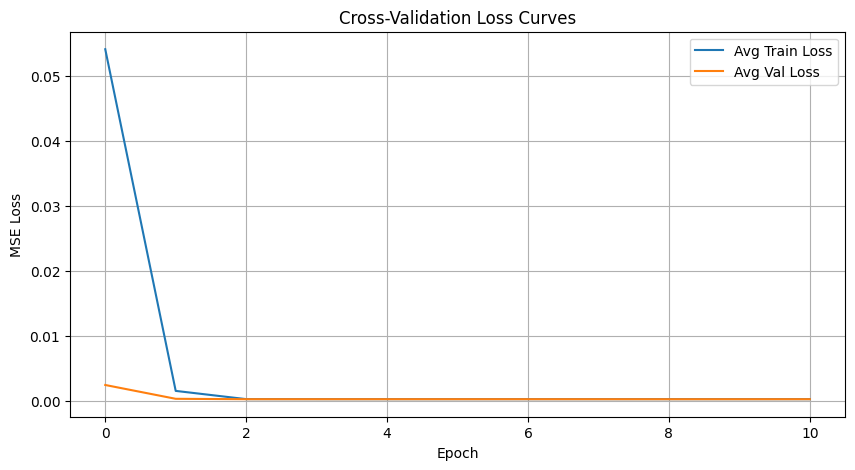

In [ ]:
# Initialize a new model object with the correct input size
model = FeedforwardNet(input_size=input_size, output_size=output_size, hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer).to(device)

# Load the best model's state dictionary into the model
model.load_state_dict(best_model_state_dict)
name = f"1ph_inv_model_h{hidden_layers}w{neurons_per_layer}.pth"
# Save the model
torch.save(model.state_dict(), name)
print(f"\n✅ Model saved as '1ph_inv_model_h{hidden_layers}w{neurons_per_layer}.pth'")

# Evaluate and visualize the results
plot_avg_loss_curves(train_losses, val_losses)
#evaluate_and_visualize(model, test_set, dataset, device, start=0, window=100)


In [98]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import re

def plot_prediction_vs_truth(df, model, hidden_layers, neurons_per_layer, start_time=0, end_time=0.1,phases_to_display=[0, 1, 2]):
    #model = FeedforwardNet(input_size=10, hidden_layers=6, neurons_per_layer=64).to(device)

    pth_path = f"1ph_inv_model_h{hidden_layers}w{neurons_per_layer}.pth"
    if not os.path.isfile(pth_path):
        print(f"⚠️ Skip: Missing model file {pth_path}")
    
    model.load_state_dict(torch.load(pth_path))
    model.eval()


    match = re.search(r"L=(?P<L>[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", df)
    if match:
        L_val = float(match.group("L"))
    else:
        L_val = None  # or fallback value

    # === Load Dataset ===
    df = pd.read_csv(df)

    # === Prepare Input ===
    X_all = df[["value","top", "bot","time_step","L_value"]].values.astype(np.float32)
    y_true_all = df[["next_value"]].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values

    # === Denormalize ===
    scaler_X, scaler_y = dataset.get_scalers()
    y_true_denorm = y_true_all
    X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)

    with torch.no_grad():
        y_pred_tensor = model(X_tensor).cpu().numpy()
    y_pred_denorm = y_pred_tensor

    # === Time Window ===

    mask = (next_time >= start_time) & (next_time <= end_time)

    # === MAE Calculation ===
    mae_Ia = mean_absolute_error(y_true_denorm[mask, 0], y_pred_denorm[mask, 0])

    # === Plot Config ===
    fig, ax1 = plt.subplots(figsize=(14, 6))


    # === Leva osa: True (deblje) i Pred (tanke)
    
    ax1.plot(next_time[mask], y_true_denorm[mask], color='teal', linewidth=2, label="True" )
    ax1.plot(next_time[mask], y_pred_denorm[mask], color='black', linewidth=1, label="Pred" )

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Current (A)")
    ax1.grid(True)

    # === Desna osa: Error
    ax2 = ax1.twinx()
    
    error = -np.abs(y_true_denorm[mask] - y_pred_denorm[mask])
    ax2.plot(next_time[mask], error, color='red', linestyle="-", linewidth=0.5, label="Error" )

    ax2.set_ylabel("−|Error| (A)", color = "red")
    #ax2.invert_yaxis()  # Nula na vrhu

    # === Naslov & Legenda
    plt.title(f"Prediction vs GT (1 Phase) | {start_time:.3f}s–{end_time:.3f}s | MAE: Ia={mae_Ia:.4f} | Inductanse: L={L_val:.7f}")

    # Samo po jednom labela u legendi
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", ncol=3)

    plt.tight_layout()
    
    #return fig

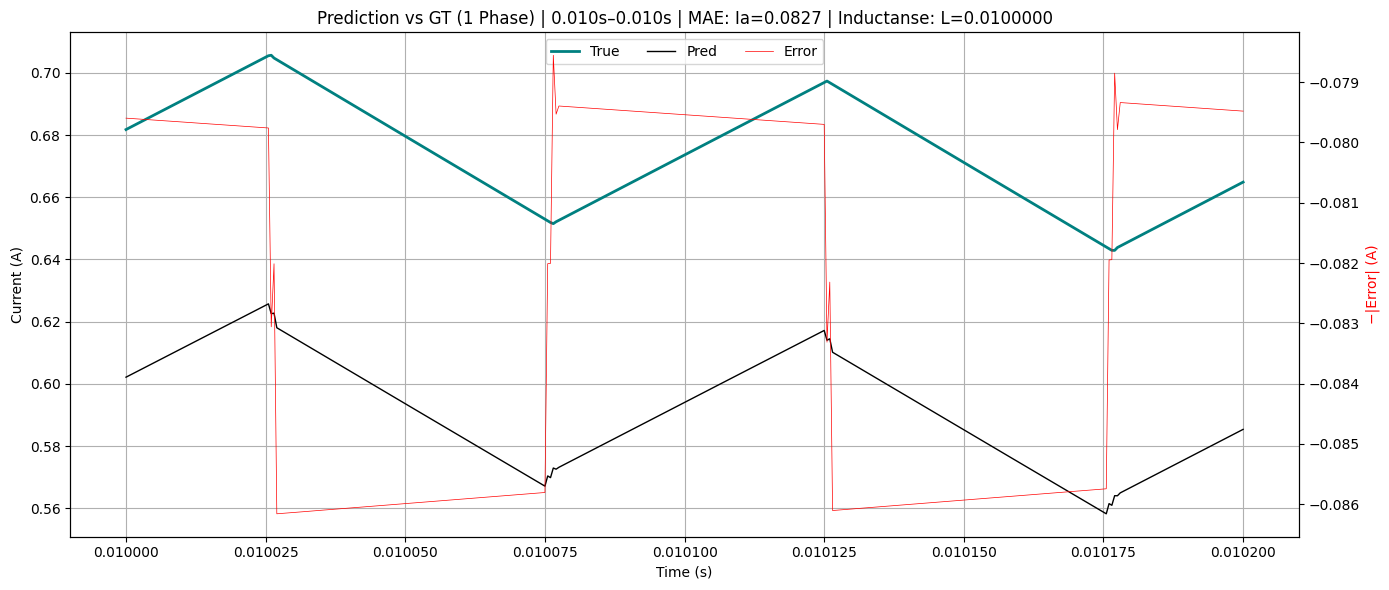

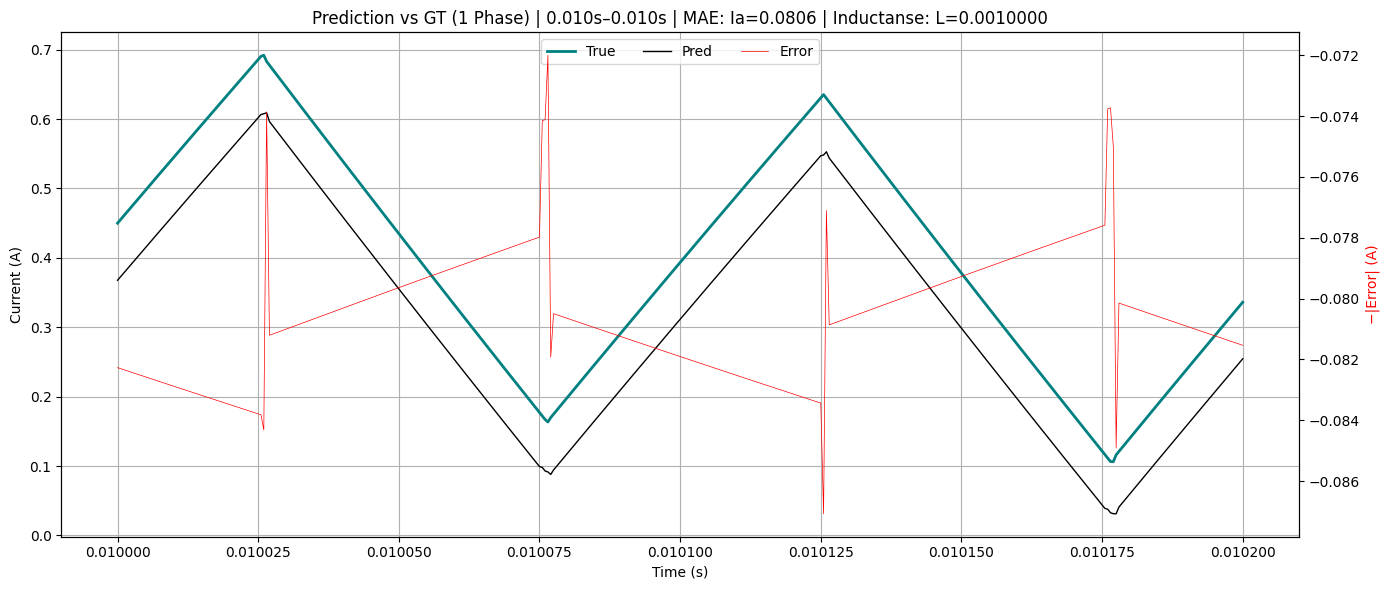

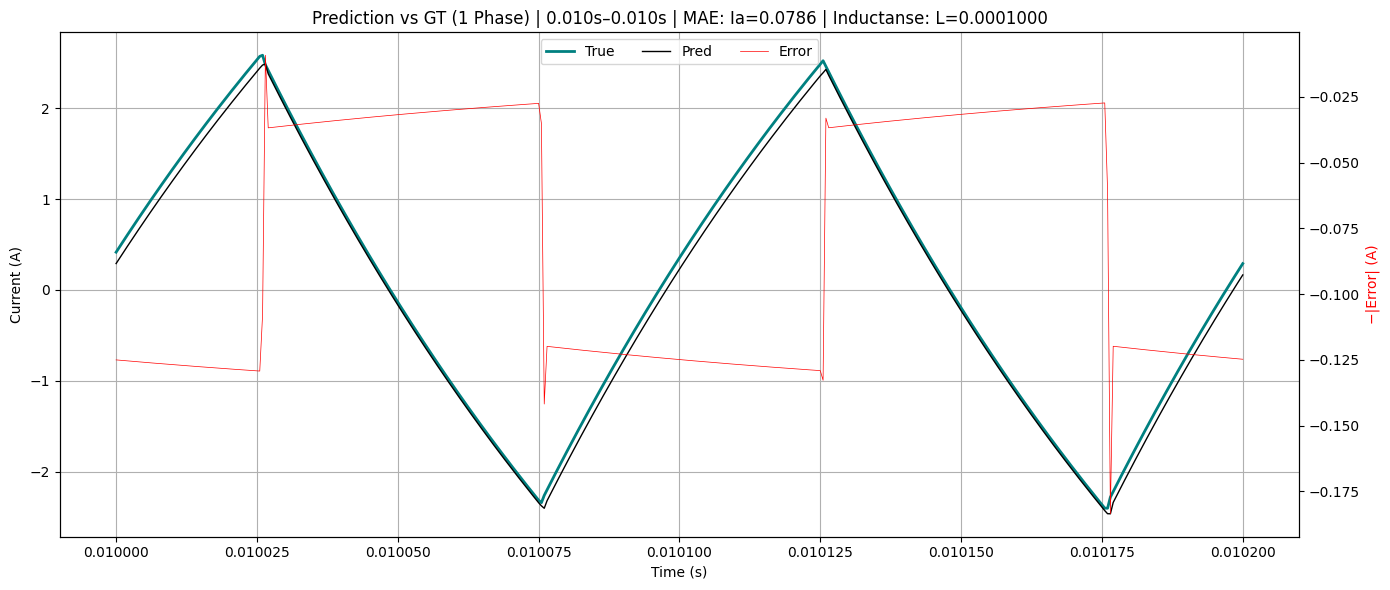

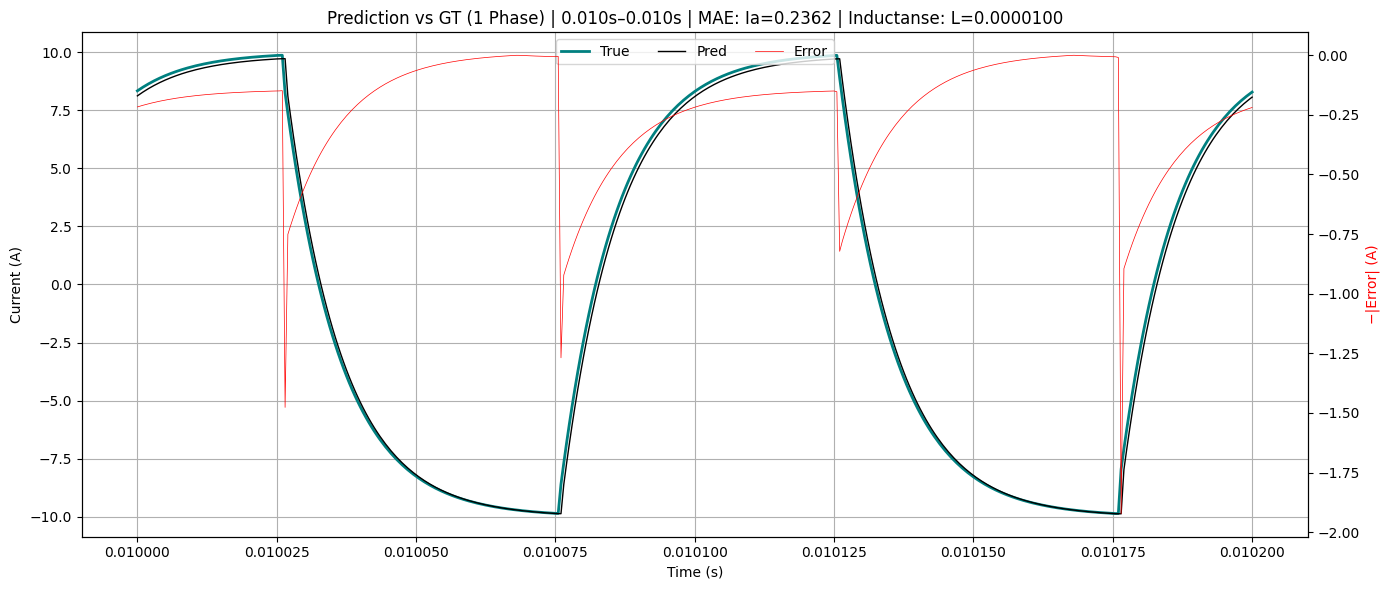

In [99]:
start_time = 0.010
end_time   = 0.0102
file_names = [  'new_igbt_leg_L=1e-2_time_step_5e-7.csv', 
                'new_igbt_leg_L=1e-3_time_step_5e-7.csv', 
                'new_igbt_leg_L=1e-4_time_step_5e-7.csv', 
                'new_igbt_leg_L=1e-5_time_step_5e-7.csv']
for f in file_names:
    plot_prediction_vs_truth(df = f,
                            start_time=start_time,
                            end_time=end_time,
                            model=model, 
                            hidden_layers=hidden_layers, 
                            neurons_per_layer=neurons_per_layer)

In [ ]:
def plot_prediction_vs_truth_1model_multi_phase(
    csv_path,
    model,
    name,
    scaler_X,
    scaler_y,
    hidden_layers,
    neurons_per_layer,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
):
   
    model.load_state_dict(torch.load(name, map_location=device))
    model.to(device)
    model.eval()

    
    df = pd.read_csv(csv_path)

    # === Izvlaci ulaze po fazi ===
    inputs_per_phase = {
        0: df[['Ia', 'topA', 'botA', 'time_step', "L_value"]].values.astype(np.float32),
        1: df[['Ib', 'topB', 'botB', 'time_step', "L_value"]].values.astype(np.float32),
        2: df[['Ic', 'topC', 'botC', 'time_step', "L_value"]].values.astype(np.float32),
    }

    targets = df[['Ia_next_value', 'Ib_next_value', 'Ic_next_value']].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values

    # === Predikcije za svaku fazu ===
    preds = []
    for i in range(3):
        X = inputs_per_phase[i]
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            y_pred = model(X_tensor).cpu().numpy()
        y_pred_denorm = y_pred
        preds.append(y_pred_denorm)

    # === Kombinuj predikcije u jedan array
    y_pred_denorm_all = np.concatenate(preds, axis=1)
    y_true_denorm = targets  # već je neskalirano

    # === Time Window
    start_time = 0.024
    end_time = 0.05
    mask = (next_time >= start_time) & (next_time <= end_time)

    # === MAE po fazi
    mae = [
        mean_absolute_error(y_true_denorm[mask, i], y_pred_denorm_all[mask, i])
        for i in range(3)
    ]

    # === Plot
    fig, ax1 = plt.subplots(figsize=(14, 6))
    phase_colors = ["teal", "orange", "seagreen"]
    truth_colors =  ["purple", "red", "pink"]

    for i in range(3):
        ax1.plot(next_time[mask], y_true_denorm[mask, i], color=truth_colors[i], linewidth=2, label=f"True Phase {i+1}")
        ax1.plot(next_time[mask], y_pred_denorm_all[mask, i], color=phase_colors[i], linestyle='--', linewidth=1, label=f"Pred {i+1}")

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Current (A)")
    ax1.grid(True)

    # === Greška sa desne strane
    ax2 = ax1.twinx()
    error_colors = ["purple", "red", "pink"]
    for i in range(3):
        err = -np.abs(y_true_denorm[mask, i] - y_pred_denorm_all[mask, i])
        ax2.plot(next_time[mask], err, color=error_colors[i], linestyle="--", linewidth=1)

    ax2.set_ylabel("−|Error| (A)")
    #ax2.invert_yaxis()  # nula na vrhu

    plt.title(
        f"Prediction per phase vs GT | MAE: Ia={mae[0]:.4f}, Ib={mae[1]:.4f}, Ic={mae[2]:.4f},  L={L_val:.4f}"
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels1, loc="upper center", ncol=3)

    plt.tight_layout()
    #return fig

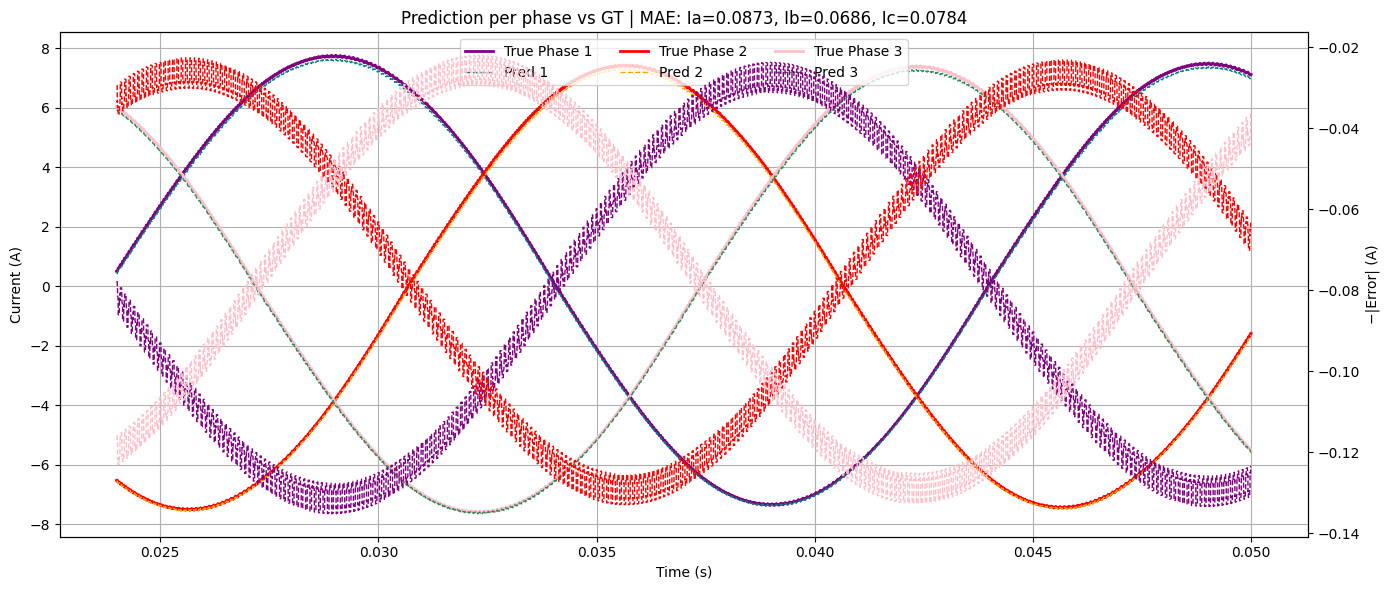

In [81]:
plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                                                   neurons_per_layer=neurons_per_layer),
                                            name=name, 
                                            csv_path='C:\\Users\\OgnjenPeric\\Desktop\\NN\\3ph_inv\\new_3ph_inv_time_step_5e-7.csv', 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=6, 
                                            neurons_per_layer=64)